In [ ]:
# Capstone Project 4
# Project Scenario
# Smart Traffic Sign Recognition System
# Scenario
# A city is building a Smart Traffic Monitoring System to improve road safety.

# Every intersection in the city will have cameras that detect traffic signs automatically.

# The system must recognize different road signs such as:

# Stop sign

# Speed limit sign

# Pedestrian crossing sign

# The system will be used in autonomous vehicles and traffic monitoring cameras.

# However, the engineers discovered two challenges:

# 1️⃣ First, the system must understand basic classification logic (learning from features).
# 2️⃣ Second, it must classify images of traffic signs captured by cameras.

# To solve this, the engineering team decided to build the system in two stages.

# Stage 1
# Learning Basic Neural Networks (Perceptron)
# Before building a full image model, the engineers want students to first implement a Perceptron-based neural network to understand how neural networks make decisions.

# The perceptron will predict whether a traffic sign means "STOP" or "NOT STOP" using extracted features.

# Dataset is available in DatasetCapstoneProject4 in the github repo link https://github.com/himanshusar123/Datasets

In [1]:
import subprocess, sys

packages = [
    'pandas',
    'numpy',
    'matplotlib',
    'seaborn',
    'scikit-learn',
]

for pkg in packages:
    try:
        __import__(pkg.replace('-','_').split('[')[0])
        print(f' {pkg} already installed')
    except ImportError:
        print(f'Installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip',
                               'install', pkg, '-q'])
        print(f' {pkg} installed')

print('\nAll dependencies ready!')

 pandas already installed
 numpy already installed
 matplotlib already installed
 seaborn already installed
Installing scikit-learn...
 scikit-learn installed

All dependencies ready!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import Perceptron
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, LeaveOneOut, cross_val_score
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline

print("Libraries imported")


Libraries imported


In [3]:
#load from file:
df = pd.read_csv('DatasetCapstoneProject4.csv')


print("TRAFFIC SIGN DATASET")
print(f"  Shape  : {df.shape}")
print(f"  Target : 'Stop_Sign'  (1=STOP, 0=NOT STOP)")
print()
display(df)


TRAFFIC SIGN DATASET
  Shape  : (10, 6)
  Target : 'Stop_Sign'  (1=STOP, 0=NOT STOP)



,Sign_ID,Red_Color_Intensity,Circular_Shape,Text_Present,Edge_Count,Stop_Sign
0,1,0.90,0,1,8,1
1,2,0.20,1,0,4,0
2,3,0.85,0,1,7,1
3,4,0.30,1,0,5,0
4,5,0.88,0,1,8,1
5,6,0.25,1,0,4,0
6,7,0.92,0,1,8,1
7,8,0.35,1,0,5,0
8,9,0.86,0,1,7,1
9,10,0.28,1,0,4,0


In [4]:
print("Target Distribution:")
print(df['Stop_Sign'].value_counts().rename({1:'STOP',0:'NOT STOP'}))
print()
print("Feature Stats:")
display(df.drop(columns=['Sign_ID']).groupby('Stop_Sign').mean().round(3).rename(
    index={0:'NOT STOP', 1:'STOP'}))


Target Distribution:
Stop_Sign
STOP        5
NOT STOP    5
Name: count, dtype: int64

Feature Stats:


,Red_Color_Intensity,Circular_Shape,Text_Present,Edge_Count
Stop_Sign,,,,
NOT STOP,0.276,1.0,0.0,4.4
STOP,0.882,0.0,1.0,7.6


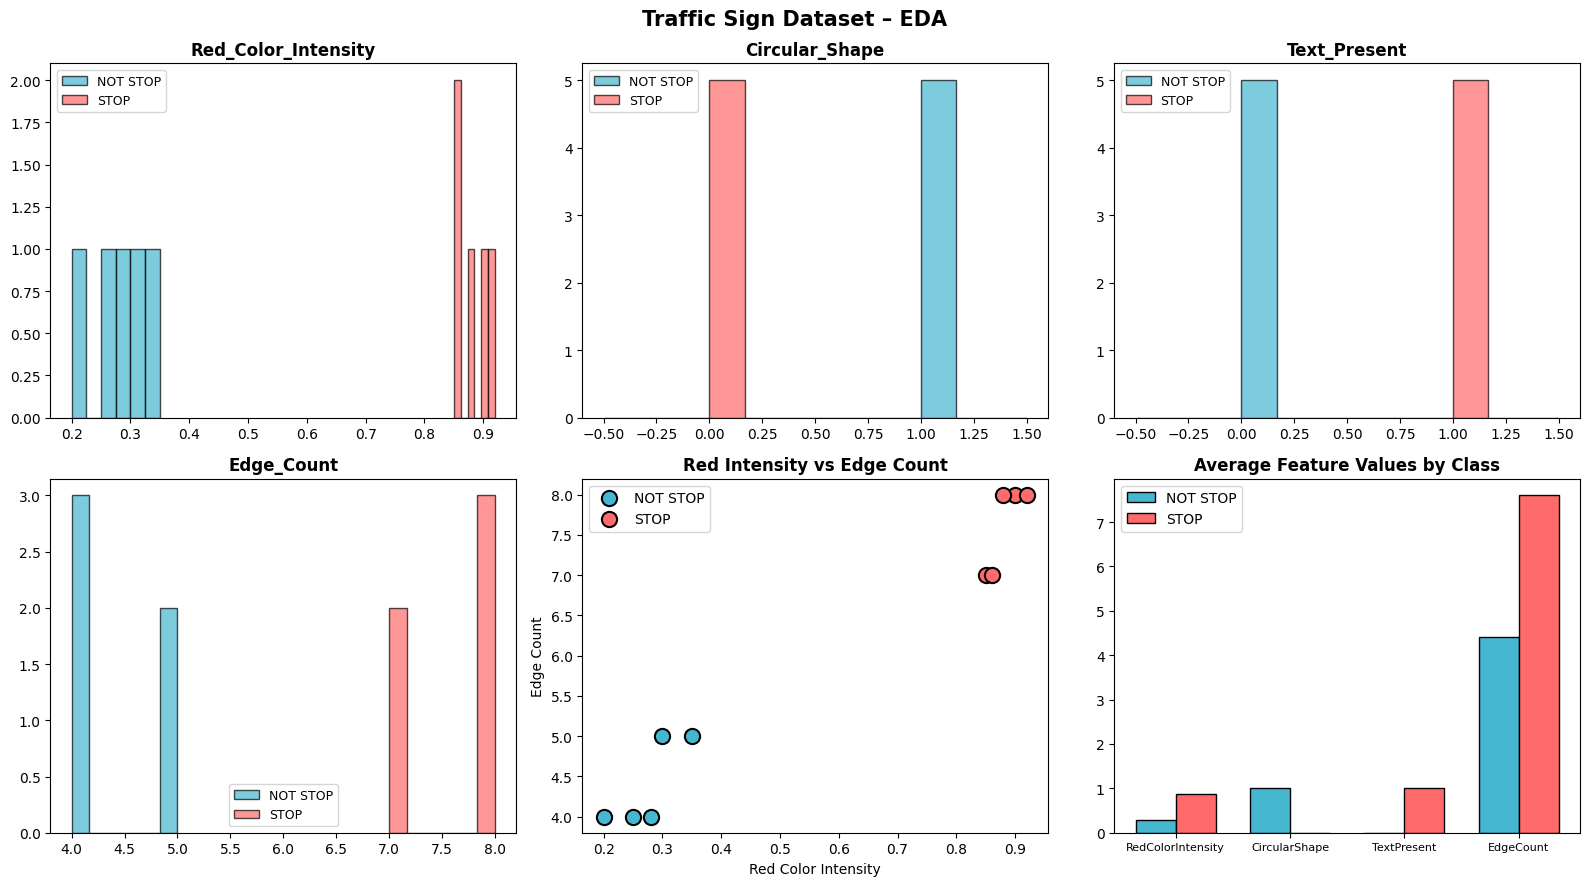

EDA complete


In [5]:
features = ['Red_Color_Intensity','Circular_Shape','Text_Present','Edge_Count']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Traffic Sign Dataset – EDA', fontsize=15, fontweight='bold')

colors_map = {0:'#45B7D1', 1:'#FF6B6B'}
label_map  = {0:'NOT STOP', 1:'STOP'}

for i, feat in enumerate(features):
    ax = axes[i//3][i%3] if i < 3 else axes[1][i-3]
    for label in [0,1]:
        subset = df[df['Stop_Sign']==label][feat]
        ax.hist(subset, bins=6, alpha=0.7, color=colors_map[label],
                label=label_map[label], edgecolor='black')
    ax.set_title(f'{feat}', fontweight='bold')
    ax.legend(fontsize=9)

ax = axes[1][1]
for label in [0,1]:
    mask = df['Stop_Sign']==label
    ax.scatter(df[mask]['Red_Color_Intensity'], df[mask]['Edge_Count'],
               c=colors_map[label], label=label_map[label],
               s=120, edgecolors='black', linewidth=1.5)
ax.set_xlabel('Red Color Intensity'); ax.set_ylabel('Edge Count')
ax.set_title('Red Intensity vs Edge Count', fontweight='bold')
ax.legend()


ax = axes[1][2]
avg = df.groupby('Stop_Sign')[features].mean()
x   = np.arange(len(features))
w   = 0.35
ax.bar(x - w/2, avg.loc[0], w, color='#45B7D1', edgecolor='black', label='NOT STOP')
ax.bar(x + w/2, avg.loc[1], w, color='#FF6B6B', edgecolor='black', label='STOP')
ax.set_xticks(x); ax.set_xticklabels([f.replace('_','') for f in features], fontsize=8)
ax.set_title('Average Feature Values by Class', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('traffic_eda.png', dpi=130, bbox_inches='tight')
plt.show()
print("EDA complete")


In [6]:
TARGET = 'Stop_Sign'
DROP   = ['Sign_ID']

X = df.drop(columns=[TARGET] + DROP)
y = df[TARGET]

feature_names = X.columns.tolist()
print("Features:", feature_names)
print("Samples :", len(X), " | STOP:", y.sum(), " | NOT STOP:", (y==0).sum())

# Scale features
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_names)

print("\nScaled feature stats:")
display(X_scaled_df.describe().round(3))


Features: ['Red_Color_Intensity', 'Circular_Shape', 'Text_Present', 'Edge_Count']
Samples : 10  | STOP: 5  | NOT STOP: 5

Scaled feature stats:


,Red_Color_Intensity,Circular_Shape,Text_Present,Edge_Count
count,10.000,10.000,10.000,10.000
mean,-0.000,0.000,0.000,0.000
std,1.054,1.054,1.054,1.054
min,-1.240,-1.000,-1.000,-1.195
25%,-0.962,-1.000,-1.000,-1.046
50%,0.069,0.000,0.000,0.000
75%,0.969,1.000,1.000,1.046
max,1.116,1.000,1.000,1.195


In [7]:
class Perceptron_Scratch:
    """
    Single-layer Perceptron from scratch.

    Forward pass  : z = Σ(wᵢxᵢ) + b
    Activation    : f(z) = 1 if z ≥ 0  else  0   (Heaviside step)
    Learning rule : Δw = η × (y - ŷ) × x
                    Δb = η × (y - ŷ)
    """

    def __init__(self, learning_rate=0.1, epochs=100, random_state=42):
        self.lr      = learning_rate
        self.epochs  = epochs
        self.rng     = np.random.default_rng(random_state)
        self.weights = None
        self.bias    = None
        self.history = []  

    @staticmethod
    def _activate(z):
        return (z >= 0).astype(int)

    def fit(self, X, y):
        X, y = np.array(X), np.array(y)
        n_samples, n_features = X.shape

        self.weights = self.rng.uniform(-0.1, 0.1, n_features)
        self.bias    = 0.0

        for epoch in range(1, self.epochs + 1):
            misclassified = 0
            for xi, yi in zip(X, y):
                z    = np.dot(xi, self.weights) + self.bias
                y_hat = self._activate(np.array([z]))[0]
                error = yi - y_hat
                if error != 0:
                    self.weights += self.lr * error * xi
                    self.bias    += self.lr * error
                    misclassified += 1

            self.history.append((epoch, misclassified, self.weights.copy()))

            if misclassified == 0:
                print(f"  Converged at epoch {epoch}  (zero errors)")
                break
        else:
            print(f"  Did not fully converge in {self.epochs} epochs  "
                  f"(final errors: {self.history[-1][1]})")

        return self

    def predict(self, X):
        z = np.dot(np.array(X), self.weights) + self.bias
        return self._activate(z)

    def score(self, X, y):
        return float(np.mean(self.predict(X) == np.array(y)))


print("Perceptron_Scratch class defined")


Perceptron_Scratch class defined


In [8]:
p_manual = Perceptron_Scratch(learning_rate=0.1, epochs=50)
print("Training Manual Perceptron...")
p_manual.fit(X_scaled, y.values)

train_acc = p_manual.score(X_scaled, y.values)
y_pred_manual = p_manual.predict(X_scaled)

print(f"\nFinal Weights : {dict(zip(feature_names, p_manual.weights.round(4)))}")
print(f"Final Bias    : {p_manual.bias:.4f}")
print(f"Training Acc  : {train_acc:.4f}  ({train_acc*100:.1f}%)")


Training Manual Perceptron...
  Converged at epoch 1  (zero errors)

Final Weights : {'Red_Color_Intensity': np.float64(0.0548), 'Circular_Shape': np.float64(-0.0122), 'Text_Present': np.float64(0.0717), 'Edge_Count': np.float64(0.0395)}
Final Bias    : 0.0000
Training Acc  : 1.0000  (100.0%)


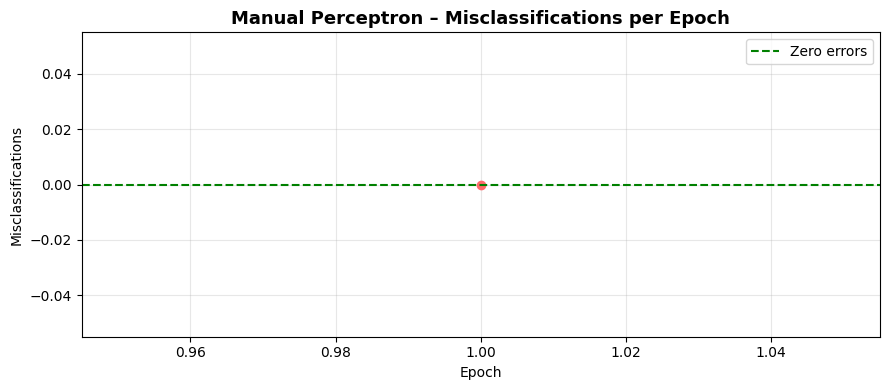

In [9]:
epochs = [h[0] for h in p_manual.history]
errors = [h[1] for h in p_manual.history]

plt.figure(figsize=(9, 4))
plt.plot(epochs, errors, color='#FF6B6B', linewidth=2.5, marker='o', markersize=6)
plt.fill_between(epochs, errors, alpha=0.2, color='#FF6B6B')
plt.title('Manual Perceptron – Misclassifications per Epoch',
          fontsize=13, fontweight='bold')
plt.xlabel('Epoch'); plt.ylabel('Misclassifications')
plt.axhline(y=0, color='green', linestyle='--', label='Zero errors')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('convergence.png', dpi=130, bbox_inches='tight')
plt.show()


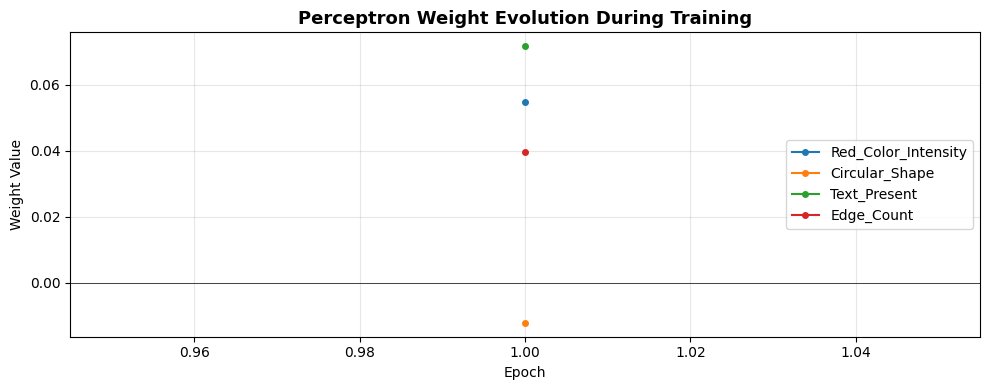

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
weight_history = np.array([h[2] for h in p_manual.history])

for i, fname in enumerate(feature_names):
    ax.plot([h[0] for h in p_manual.history], weight_history[:, i],
            marker='o', markersize=4, label=fname)

ax.set_title('Perceptron Weight Evolution During Training',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Weight Value')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.legend(loc='right'); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('weight_evolution.png', dpi=130, bbox_inches='tight')
plt.show()


In [11]:
sk_pipeline = Pipeline([
    ('scaler',     StandardScaler()),
    ('perceptron', Perceptron(eta0=0.1, max_iter=100,
                              random_state=42, tol=1e-3))
])

loo     = LeaveOneOut()
loo_scores = cross_val_score(sk_pipeline, X, y, cv=loo, scoring='accuracy')

sk_pipeline.fit(X_scaled, y)          
y_pred_sk = sk_pipeline.named_steps['perceptron'].predict(X_scaled)


print("SKLEARN PERCEPTRON")

print(f"  LOO-CV Accuracy  : {loo_scores.mean():.4f}  ± {loo_scores.std():.4f}")
print(f"  Training Accuracy: {accuracy_score(y, y_pred_sk):.4f}")
print()
print(classification_report(y, y_pred_sk,
      target_names=['NOT STOP','STOP']))


SKLEARN PERCEPTRON
  LOO-CV Accuracy  : 1.0000  ± 0.0000
  Training Accuracy: 1.0000

              precision    recall  f1-score   support

    NOT STOP       1.00      1.00      1.00         5
        STOP       1.00      1.00      1.00         5

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



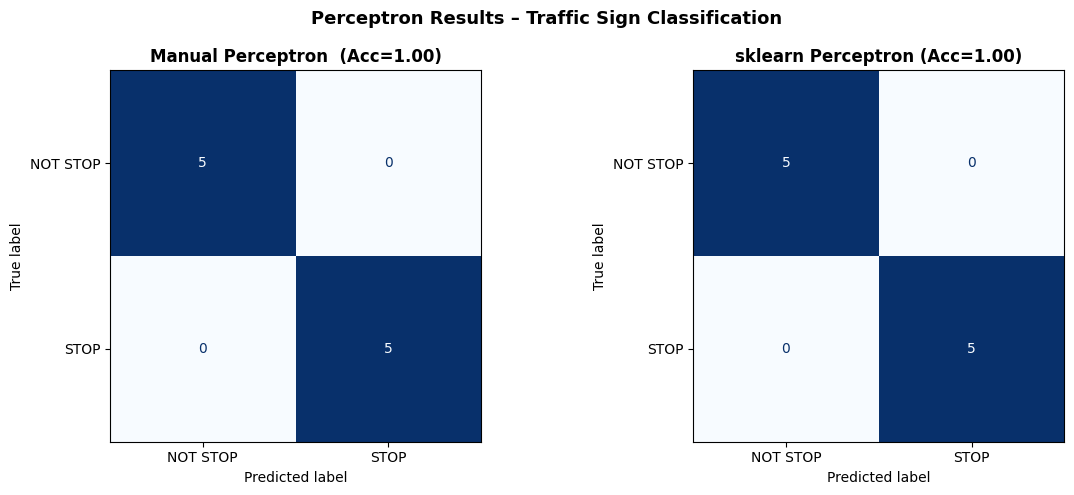

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Perceptron Results – Traffic Sign Classification',
             fontsize=13, fontweight='bold')

for ax, y_pred, title in zip(
    axes,
    [y_pred_manual, y_pred_sk],
    [f'Manual Perceptron  (Acc={train_acc:.2f})',
     f'sklearn Perceptron (Acc={accuracy_score(y,y_pred_sk):.2f})']
):
    cm = confusion_matrix(y, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['NOT STOP','STOP']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=130, bbox_inches='tight')
plt.show()


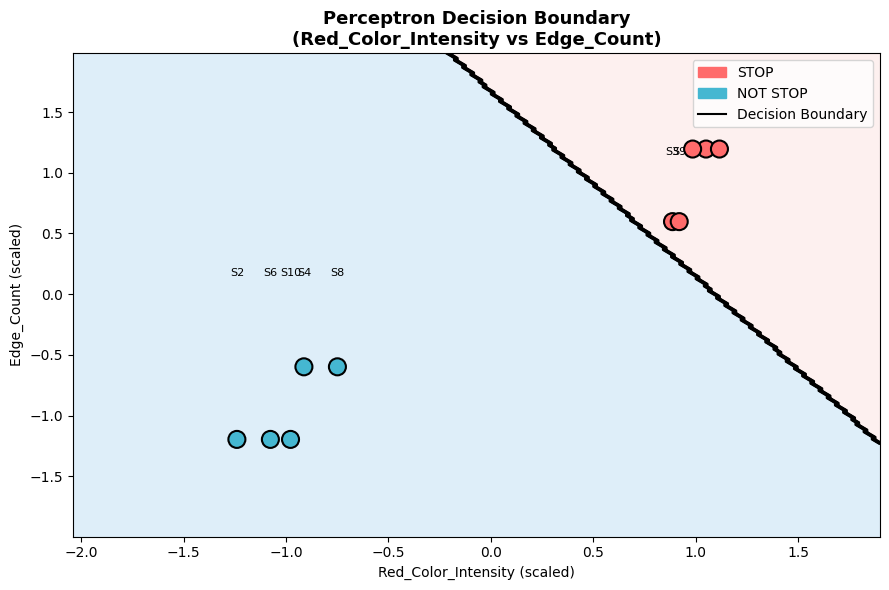

2D Perceptron Accuracy: 1.0000


In [13]:
feat_x, feat_y = 'Red_Color_Intensity', 'Edge_Count'
idx_x = feature_names.index(feat_x)
idx_y = feature_names.index(feat_y)

X_2d = X_scaled[:, [idx_x, idx_y]]

p2d = Perceptron(eta0=0.1, max_iter=200, random_state=42)
p2d.fit(X_2d, y)

h = 0.02
x_min, x_max = X_2d[:,0].min()-0.8, X_2d[:,0].max()+0.8
y_min, y_max = X_2d[:,1].min()-0.8, X_2d[:,1].max()+0.8
xx, yy = np.meshgrid(np.arange(x_min,x_max,h), np.arange(y_min,y_max,h))
Z = p2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(9, 6))
cmap_bg  = ListedColormap(['#AED6F1','#FADBD8'])
cmap_pts = ListedColormap(['#45B7D1','#FF6B6B'])
plt.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_bg)
plt.contour(xx, yy, Z, colors='black', linewidths=1.5)

scatter = plt.scatter(X_2d[:,0], X_2d[:,1], c=y,
                      cmap=cmap_pts, s=150,
                      edgecolors='black', linewidth=1.5, zorder=5)

for i, (xi, yi_val) in enumerate(zip(X_2d, y)):
    plt.annotate(f'S{df["Sign_ID"].iloc[i]}', (xi[0], yi_val+0.15),
                 fontsize=8, ha='center')

plt.xlabel(f'{feat_x} (scaled)'); plt.ylabel(f'{feat_y} (scaled)')
plt.title(f'Perceptron Decision Boundary\n({feat_x} vs {feat_y})',
          fontsize=13, fontweight='bold')
stop_patch   = mpatches.Patch(color='#FF6B6B', label='STOP')
nostop_patch = mpatches.Patch(color='#45B7D1', label='NOT STOP')
boundary_line = plt.Line2D([0],[0], color='black', lw=1.5, label='Decision Boundary')
plt.legend(handles=[stop_patch, nostop_patch, boundary_line])
plt.tight_layout()
plt.savefig('decision_boundary.png', dpi=130, bbox_inches='tight')
plt.show()
print(f"2D Perceptron Accuracy: {p2d.score(X_2d, y):.4f}")


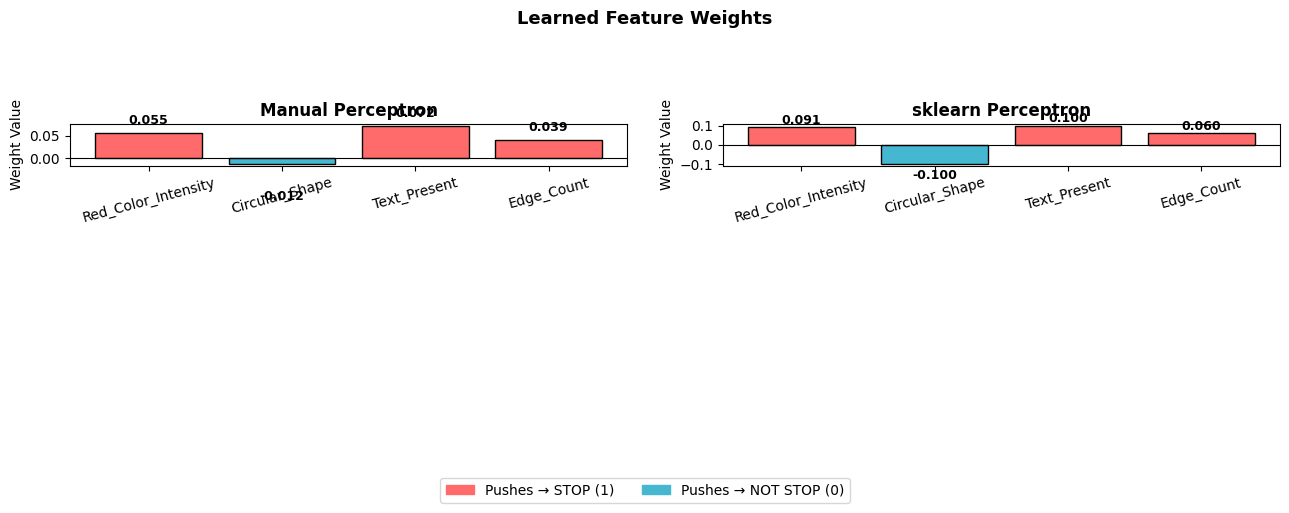

Insight: Positive weights → push prediction toward STOP
         Negative weights → push prediction toward NOT STOP


In [14]:

w_manual = p_manual.weights
w_sklearn = sk_pipeline.named_steps['perceptron'].coef_[0]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Learned Feature Weights', fontsize=13, fontweight='bold')

for ax, weights, title in zip(
    axes,
    [w_manual, w_sklearn],
    ['Manual Perceptron', 'sklearn Perceptron']
):
    colors = ['#FF6B6B' if w>0 else '#45B7D1' for w in weights]
    bars = ax.bar(feature_names, weights, color=colors, edgecolor='black')
    ax.axhline(y=0, color='black', linewidth=0.8)
    ax.set_title(f'{title}', fontweight='bold')
    ax.set_ylabel('Weight Value')
    ax.tick_params(axis='x', rotation=15)
    for bar, w in zip(bars, weights):
        ax.text(bar.get_x()+bar.get_width()/2,
                w + (0.02 if w >= 0 else -0.08),
                f'{w:.3f}', ha='center', fontsize=9, fontweight='bold')

red_patch  = mpatches.Patch(color='#FF6B6B', label='Pushes → STOP (1)')
blue_patch = mpatches.Patch(color='#45B7D1', label='Pushes → NOT STOP (0)')
fig.legend(handles=[red_patch, blue_patch], loc='lower center',
           ncol=2, bbox_to_anchor=(0.5,-0.02))
plt.tight_layout()
plt.savefig('feature_weights.png', dpi=130, bbox_inches='tight')
plt.show()

print("Insight: Positive weights → push prediction toward STOP")
print("         Negative weights → push prediction toward NOT STOP")


In [15]:
def classify_traffic_sign(red_intensity, circular_shape, text_present, edge_count):
    """
    Classify a traffic sign as STOP or NOT STOP.

    Parameters
    ----------
    red_intensity  : float  0.0–1.0  (how red the sign is)
    circular_shape : int    1=circle, 0=not
    text_present   : int    1=has text, 0=none
    edge_count     : int    number of edges detected

    Returns
    -------
    dict with prediction and analysis
    """
    features_raw = np.array([[red_intensity, circular_shape, text_present, edge_count]])
    features_scaled = scaler.transform(features_raw)
    pred = p_manual.predict(features_scaled)[0]

    score = np.dot(features_scaled[0], p_manual.weights) + p_manual.bias

    return {
        'prediction' : 'STOP ' if pred == 1 else 'NOT STOP ',
        'label'      : int(pred),
        'score'      : round(float(score), 4),
        'confidence' : 'High' if abs(score) > 0.5 else 'Low',
        'action'     : 'HALT – Vehicle must stop' if pred else 'PROCEED – No stop required'
    }




print("TRAFFIC SIGN RECOGNITION SYSTEM  –  Batch Classification")

print(f"{'Sign':<6} {'R-Int':>6} {'Circ':>5} {'Text':>5} {'Edges':>6} "
      f"{'Actual':>9} {'Predicted':>10} {'Correct':>8}")
print("-" * 70)

correct = 0
for _, row in df.iterrows():
    result = classify_traffic_sign(
        row['Red_Color_Intensity'], row['Circular_Shape'],
        row['Text_Present'], row['Edge_Count']
    )
    actual = 'STOP' if row['Stop_Sign']==1 else 'NOT STOP'
    match  = 'Yes' if result['label'] == row['Stop_Sign'] else 'No'
    if result['label'] == row['Stop_Sign']: correct += 1
    print(f"S{row['Sign_ID']:<5} {row['Red_Color_Intensity']:>6.2f} "
          f"{row['Circular_Shape']:>5} {row['Text_Present']:>5} "
          f"{row['Edge_Count']:>6}  {actual:>9}  {result['prediction']:>12}  {match}")


print(f"Overall Accuracy: {correct}/{len(df)}  ({correct/len(df):.1%})")


TRAFFIC SIGN RECOGNITION SYSTEM  –  Batch Classification
Sign    R-Int  Circ  Text  Edges    Actual  Predicted  Correct
----------------------------------------------------------------------
S1.0     0.90   0.0   1.0    8.0       STOP         STOP   Yes
S2.0     0.20   1.0   0.0    4.0   NOT STOP     NOT STOP   Yes
S3.0     0.85   0.0   1.0    7.0       STOP         STOP   Yes
S4.0     0.30   1.0   0.0    5.0   NOT STOP     NOT STOP   Yes
S5.0     0.88   0.0   1.0    8.0       STOP         STOP   Yes
S6.0     0.25   1.0   0.0    4.0   NOT STOP     NOT STOP   Yes
S7.0     0.92   0.0   1.0    8.0       STOP         STOP   Yes
S8.0     0.35   1.0   0.0    5.0   NOT STOP     NOT STOP   Yes
S9.0     0.86   0.0   1.0    7.0       STOP         STOP   Yes
S10.0    0.28   1.0   0.0    4.0   NOT STOP     NOT STOP   Yes
Overall Accuracy: 10/10  (100.0%)


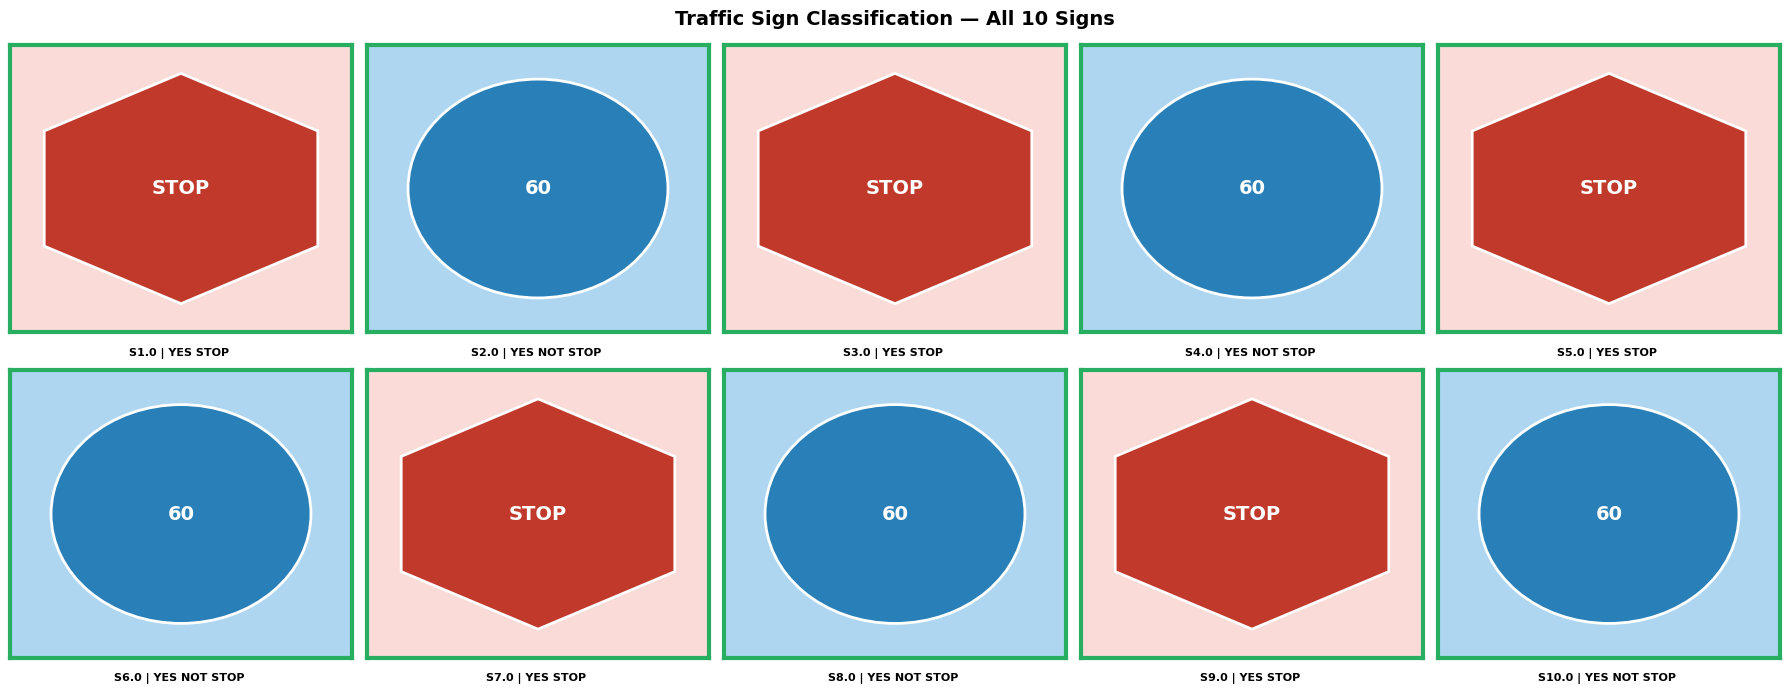

In [16]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle('Traffic Sign Classification — All 10 Signs', fontsize=14, fontweight='bold')

for idx, (_, row) in enumerate(df.iterrows()):
    ax  = axes[idx//5][idx%5]
    res = classify_traffic_sign(row['Red_Color_Intensity'], row['Circular_Shape'],
                                row['Text_Present'], row['Edge_Count'])
    is_stop  = row['Stop_Sign'] == 1
    correct  = res['label'] == row['Stop_Sign']
    bg_color = '#FADBD8' if is_stop else '#AED6F1'
    fc_color = '#C0392B' if is_stop else '#2980B9'

    ax.set_facecolor(bg_color)
    if is_stop:
        shape = plt.Polygon([[0.5,0.9],[0.9,0.7],[0.9,0.3],[0.5,0.1],
                              [0.1,0.3],[0.1,0.7]], closed=True,
                             facecolor=fc_color, edgecolor='white', lw=2)
    else:
        circle = plt.Circle((0.5,0.5), 0.38, facecolor=fc_color,
                             edgecolor='white', lw=2)
        ax.add_patch(circle)
        shape = None
    if shape: ax.add_patch(shape)

    sign_text = 'STOP' if is_stop else '60'
    ax.text(0.5, 0.5, sign_text, ha='center', va='center',
            fontsize=14, fontweight='bold', color='white')
    ax.text(0.5, -0.08, f"S{row['Sign_ID']} | {'YES' if correct else 'NO'} {res['prediction']}",
            ha='center', transform=ax.transAxes, fontsize=8, fontweight='bold')
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor('#27AE60' if correct else '#E74C3C')
        spine.set_linewidth(3)

plt.tight_layout()
plt.savefig('sign_cards.png', dpi=130, bbox_inches='tight')
plt.show()
